In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train = np.load("./data/processed/dataset_train_shortened.npz", allow_pickle=True)
X_train = train["X"]
y_train = train["y"]          # int {0,1}

full = np.load("./data/processed/dataset_full.npz", allow_pickle=True)
X_full = full["X"]
K0_full = full["K0"]


In [3]:
print("Number of features:", X_full.shape[1])
print("TRAIN", y_train.shape)
print(X_train.shape)

Number of features: 30
TRAIN (47222,)
(47222, 30)


In [4]:
def run_supervised_pipeline(model, X_train, y_train, X_full):
    """
    Train a supervised classifier on deep-phase data and
    evaluate its probabilistic predictions on the full dataset.

    Returns:
        train_score : training accuracy (sanity check only)
        P_A         : predicted probability of phase A for all samples
    """

    # Fit the model on deep phase A/C training data
    model.fit(X_train, y_train)

    # Training accuracy (used only as a consistency check;
    # not used to assess the phase transition)
    train_score = model.score(X_train, y_train)

    # Obtain probabilistic predictions for the full dataset
    if hasattr(model, "predict_proba"):
        # Preferred case: model provides calibrated probabilities
        P_A = model.predict_proba(X_full)[:, 1]
    else:
        # Fallback: map decision function scores to (0,1) via sigmoid
        #barely ever it happens
        scores = model.decision_function(X_full)
        P_A = 1.0 / (1.0 + np.exp(-scores))

    return train_score, P_A


In [5]:
def mean_and_susceptibility_vs_K0(P_A, K0_full):
    """
    Compute the mean phase-C probability and its susceptibility χ
    as a function of κ₀.

    χ is defined as the variance of Pr(C) at fixed κ₀.

    Returns:
        mean_P_C : ⟨Pr(C)⟩(κ₀)
        chi_P_C  : χ(κ₀)
    """

    # Assemble predictions and κ₀ values into a DataFrame
    df = pd.DataFrame({
        "K0": K0_full,
        "P_C": 1.0 - P_A   # convert Pr(A) -> Pr(C)
    })

    # Group by κ₀
    grouped = df.groupby("K0")["P_C"]

    # Mean phase-C probability
    mean_P_C = grouped.mean()

    # Susceptibility (variance of Pr(C))
    chi_P_C = grouped.var()

    return mean_P_C, chi_P_C


In [6]:
def extract_k0_crit(chi_series):
    """
    Extract the critical κ₀ as the location of the maximum
    of the susceptibility χ.

    Returns:
        k0_crit : κ₀ value at which χ is maximal
        chi_max : maximum value of χ
    """
    k0_values = chi_series.index.values
    chi_values = chi_series.values

    idx_max = np.argmax(chi_values)
    return k0_values[idx_max], chi_values[idx_max]


In [7]:
def plot_multi_transition(curves, calibrated=True, title="A–C transition"):
    """
    Plot ⟨Pr(C)⟩ vs κ₀ for multiple classifiers on the same axes.
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    label_key = "calibrated" if calibrated else "uncalibrated"

    # Plot mean phase-C probability for each model
    for model_name, model_curves in curves.items():
        mean_P = model_curves[label_key]["mean"]

        ax.plot(
            mean_P.index,
            mean_P.values,
            marker="o",
            linewidth=2,
            label=model_name
        )

    # Highlight expected transition region
    ax.axvspan(4.74, 4.79, color="gray", alpha=0.2)
    ax.axvline(4.77, linestyle=":", color="black")

    ax.set_xlabel(r"$\kappa_0$")
    ax.set_ylabel(r"$\langle \mathrm{Pr}(d_j(\kappa_0)\in C)\rangle$")
    ax.set_title(
        title + (" (calibrated)" if calibrated else " (uncalibrated)")
    )
    ax.legend()
    ax.grid(True)

    plt.show()


In [8]:
def plot_multi_chi(curves, calibrated=True, title="Susceptibility χ"):
    """
    Plot susceptibility χ(κ₀) for multiple classifiers.
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    label_key = "calibrated" if calibrated else "uncalibrated"

    for model_name, model_curves in curves.items():
        chi = model_curves[label_key]["chi"]

        ax.plot(
            chi.index,
            chi.values,
            linewidth=2,
            label=model_name
        )

    ax.set_xlabel(r"$\kappa_0$")
    ax.set_ylabel(r"$\chi$")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

    plt.show()


In [9]:
def plot_calibration_effect(model_name, curves):
    """
    Compare calibrated vs uncalibrated ⟨Pr(C)⟩ curves
    for a single classifier.
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    for label, style in [("uncalibrated", "--"), ("calibrated", "-")]:
        mean_P = curves[model_name][label]["mean"]
        ax.plot(
            mean_P.index,
            mean_P.values,
            style,
            label=label,
            linewidth=2
        )

    ax.set_xlabel(r"$\kappa_0$")
    ax.set_ylabel(r"$\langle \mathrm{Pr}(d_j(\kappa_0)\in C)\rangle$")
    ax.set_title(f"{model_name}: calibration effect")
    ax.legend()
    ax.grid(True)
    plt.show()



In [10]:
def plot_chi_calibration_effect(model_name, curves):
    """
    Compare calibrated vs uncalibrated susceptibility χ
    for a single classifier.
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    for label, style in [("uncalibrated", "--"), ("calibrated", "-")]:
        chi = curves[model_name][label]["chi"]
        ax.plot(
            chi.index,
            chi.values,
            style,
            label=label,
            linewidth=2
        )

    ax.set_xlabel(r"$\kappa_0$")
    ax.set_ylabel(r"$\chi$")
    ax.set_title(f"{model_name}: susceptibility χ")
    ax.legend()
    ax.grid(True)
    plt.show()


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def build_model(base_model, calibrated=True):
    """
    Construct a classifier with optional probability calibration.

    All models are wrapped in a pipeline with feature standardization.
    Logistic Regression is already probabilistic and is not calibrated again.
    """
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", base_model)
    ])

    if not calibrated:
        return pipe

    # Logistic regression already outputs calibrated probabilities
    if isinstance(base_model, LogisticRegression):
        return pipe

    # Apply Platt scaling to obtain calibrated probabilities
    return CalibratedClassifierCV(
        pipe,
        method="sigmoid",
        cv=3
    )



In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=0),
    "Gradient Boosted Trees": GradientBoostingClassifier(random_state=0),
    "kNN": KNeighborsClassifier(n_neighbors=15),
    "SVM (RBF)": SVC(kernel="rbf", probability=True),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(50,50), max_iter=500)
}


In [13]:
# Containers for numerical results and full curves
results = []
curves = {}


rng = np.random.default_rng(0)
perm = rng.permutation(len(X_train))

# apply it to both arrays
X_train = X_train[perm]
y_train = y_train[perm]

perm = rng.permutation(len(X_full))

X_full = X_full[perm]
K0_full = K0_full[perm]

# Loop over all classifiers
for name, base_model in models.items():
    print(f"\n=== {name} ===")

    curves[name] = {}

    # Compare uncalibrated vs calibrated versions
    for calibrated in [False, True]:
        label = "calibrated" if calibrated else "uncalibrated"

        model = build_model(base_model, calibrated=calibrated)

        t0 = time.perf_counter()
        train_score, P_A = run_supervised_pipeline(
            model, X_train, y_train, X_full
        )
        elapsed = time.perf_counter() - t0

        # Compute ⟨Pr(C)⟩, susceptibility χ, and κ₀,crit
        mean_P_C, chi_P_C = mean_and_susceptibility_vs_K0(P_A, K0_full)
        k0_crit, chi_max = extract_k0_crit(chi_P_C)

        # Store curves for plotting
        curves[name][label] = {
            "mean": mean_P_C,
            "chi": chi_P_C
        }

        # Store numerical summary
        results.append({
            "model": name,
            "calibrated": calibrated,
            "train_accuracy": train_score,
            "k0_crit": k0_crit,
            "chi_max": chi_max,
            "time_sec": elapsed
        })

        print(
            f"{label:12s} | "
            f"acc = {train_score:.5f} | "
            f"k0_crit = {k0_crit:.4f} | "
            f"time = {elapsed:.2f}s"
        )


=== Logistic Regression ===
uncalibrated | acc = 1.00000 | k0_crit = 4.7800 | time = 1.42s
calibrated   | acc = 1.00000 | k0_crit = 4.7800 | time = 1.35s

=== Decision Tree ===
uncalibrated | acc = 1.00000 | k0_crit = 4.7800 | time = 1.37s
calibrated   | acc = 1.00000 | k0_crit = 4.7800 | time = 5.26s

=== Random Forest ===
uncalibrated | acc = 1.00000 | k0_crit = 4.7700 | time = 26.73s
calibrated   | acc = 1.00000 | k0_crit = 4.7700 | time = 75.42s

=== Gradient Boosted Trees ===
uncalibrated | acc = 1.00000 | k0_crit = 4.7700 | time = 22.05s
calibrated   | acc = 1.00000 | k0_crit = 4.7700 | time = 54.19s

=== kNN ===
uncalibrated | acc = 1.00000 | k0_crit = 4.7700 | time = 387.79s
calibrated   | acc = 1.00000 | k0_crit = 4.7700 | time = 793.59s

=== SVM (RBF) ===
uncalibrated | acc = 1.00000 | k0_crit = 4.7600 | time = 59.31s
calibrated   | acc = 1.00000 | k0_crit = 4.7600 | time = 159.78s

=== Neural Network ===
uncalibrated | acc = 1.00000 | k0_crit = 4.7800 | time = 6.42s
calibra

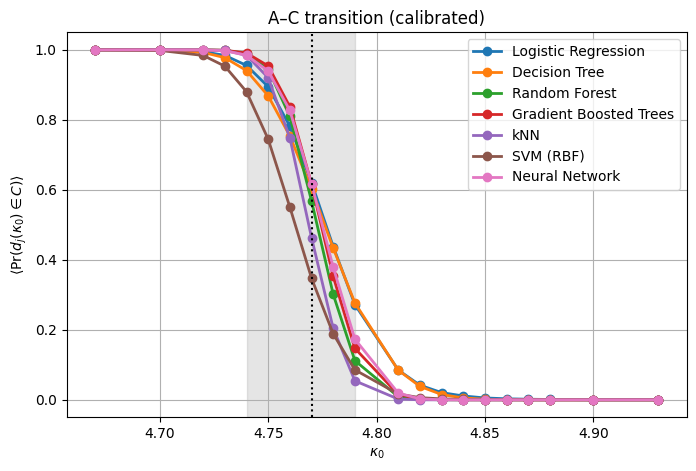

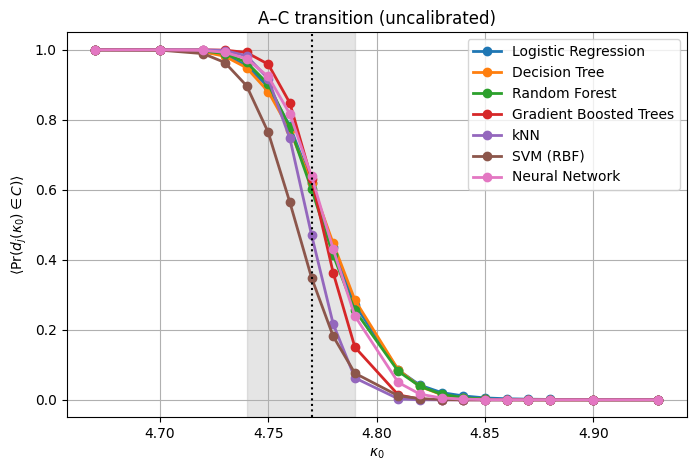

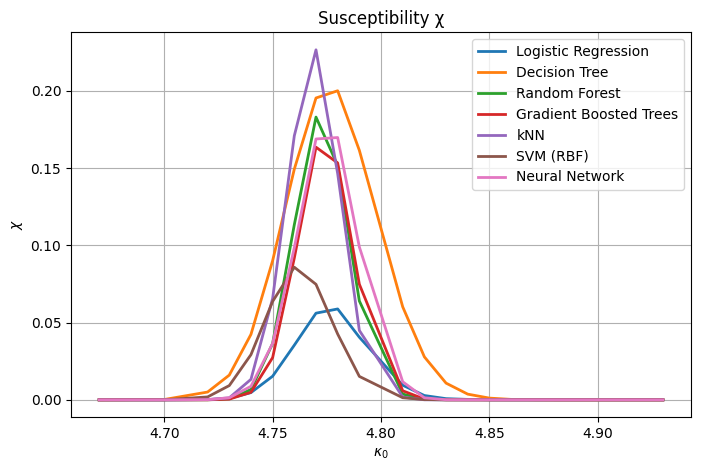

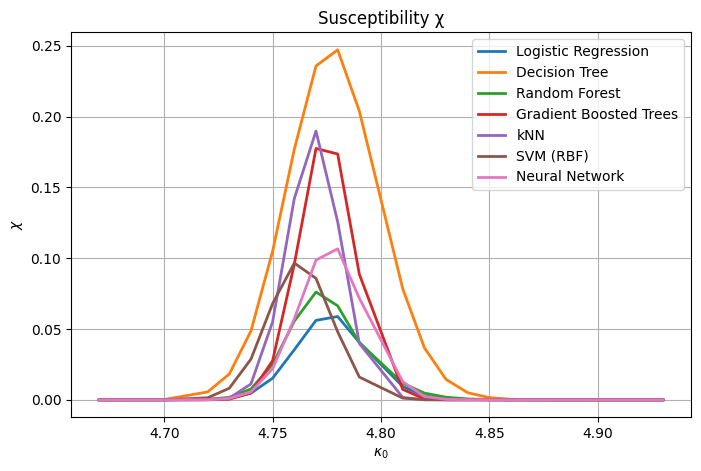

In [14]:
# calibrated curves (paper-faithful)
plot_multi_transition(curves, calibrated=True)

# uncalibrated curves (for comparison)
plot_multi_transition(curves, calibrated=False)

plot_multi_chi(curves, calibrated=True)
plot_multi_chi(curves, calibrated=False)



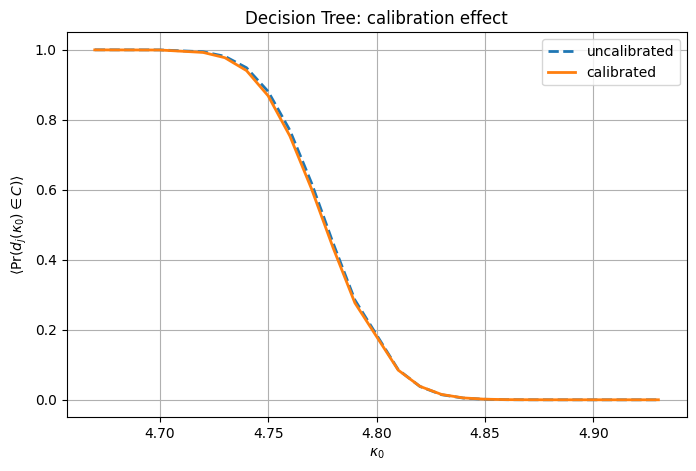

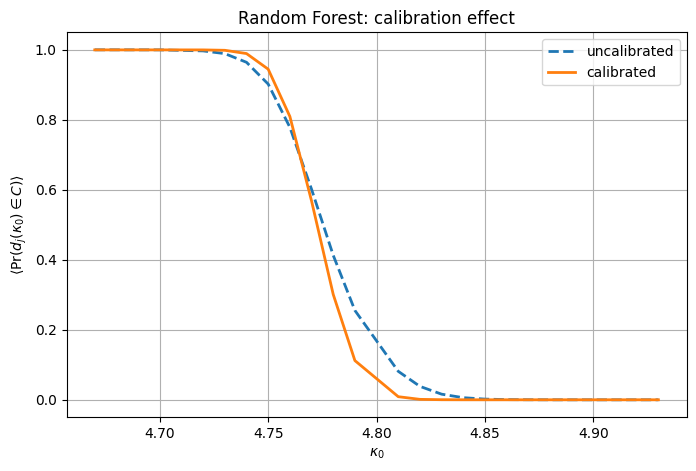

In [15]:
plot_calibration_effect("Decision Tree", curves)
plot_calibration_effect("Random Forest", curves)